<a href="https://colab.research.google.com/github/BhaveshS0524/bank-marketing-subscription-prediction/blob/main/advanced_bank_marketing_ml_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Bank Marketing ML Project

This notebook upgrades the previous project into a **more advanced Data Science pipeline**.

Additional upgrades included:
1. Multiple ML model comparison
2. Feature scaling
3. ROC-AUC evaluation
4. Hyperparameter tuning
5. Model comparison table


## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

## Load Dataset

In [2]:
df = pd.read_csv('bank.csv')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [4]:
df.shape

(11162, 17)

In [5]:
df['deposit'].value_counts()

,count
deposit,
no,5873
yes,5289


## Data Exploration

In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


## Data Cleaning

In [7]:
df['deposit'] = df['deposit'].map({'yes': 1, 'no': 0})

In [8]:
df['deposit'].unique()

array([1, 0])

## Feature Engineering

In [9]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,age,balance,day,duration,campaign,pdays,previous,deposit,job_blue-collar,job_entrepreneur,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,59,2343,5,1042,1,-1,0,1,False,False,...,False,False,False,True,False,False,False,False,False,True
1,56,45,5,1467,1,-1,0,1,False,False,...,False,False,False,True,False,False,False,False,False,True
2,41,1270,5,1389,1,-1,0,1,False,False,...,False,False,False,True,False,False,False,False,False,True
3,55,2476,5,579,1,-1,0,1,False,False,...,False,False,False,True,False,False,False,False,False,True
4,54,184,5,673,2,-1,0,1,False,False,...,False,False,False,True,False,False,False,False,False,True


## Split Features and Target

In [10]:
X = df.drop('deposit', axis=1)
y = df['deposit']

In [14]:
print(X.shape)
print(y.shape)

(11162, 42)
(11162,)


In [15]:
X.select_dtypes(include='object').columns

Index([], dtype='object')

## Train Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Training

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8410210479175997
[[956 210]
 [145 922]]
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1166
           1       0.81      0.86      0.84      1067

    accuracy                           0.84      2233
   macro avg       0.84      0.84      0.84      2233
weighted avg       0.84      0.84      0.84      2233



In [17]:
print(X.shape)

(11162, 42)


## Predictions

In [18]:
log_pred = log_model.predict(X_test_scaled)
rf_pred = rf_model.predict(X_test)

## Model Evaluation

In [19]:
print('Logistic Regression Accuracy:', accuracy_score(y_test, log_pred))
print('Random Forest Accuracy:', accuracy_score(y_test, rf_pred))

Logistic Regression Accuracy: 0.8083296014330497
Random Forest Accuracy: 0.8410210479175997


## ROC AUC

In [20]:
log_probs = log_model.predict_proba(X_test_scaled)[:,1]
rf_probs = rf_model.predict_proba(X_test)[:,1]

print('Logistic ROC-AUC:', roc_auc_score(y_test, log_probs))
print('Random Forest ROC-AUC:', roc_auc_score(y_test, rf_probs))

Logistic ROC-AUC: 0.9001335881850816
Random Forest ROC-AUC: 0.9127766408760556


## ROC Curve

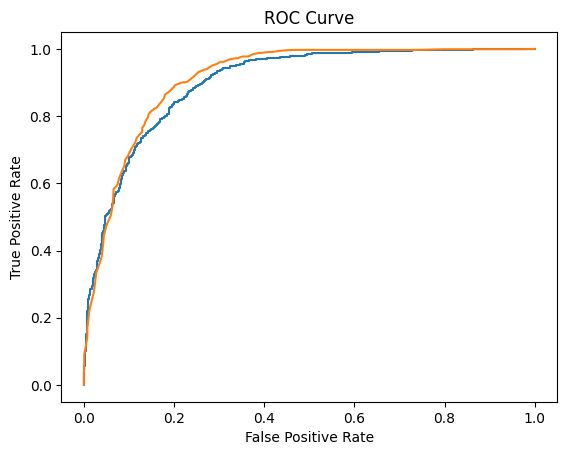

In [21]:
fpr1, tpr1, _ = roc_curve(y_test, log_probs)
fpr2, tpr2, _ = roc_curve(y_test, rf_probs)

plt.plot(fpr1, tpr1)
plt.plot(fpr2, tpr2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

## Hyperparameter Tuning (Random Forest)

In [24]:
param_grid = {
'n_estimators':[100,200],
'max_depth':[5,10,None]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

print('Best Parameters:', grid.best_params_)

Best Parameters: {'max_depth': None, 'n_estimators': 100}


## Train Final Model with Best Parameters

In [25]:
best_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

best_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Make Predictions

In [27]:
y_pred_best = best_rf.predict(X_test)

## Evaluate the Model

In [28]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Accuracy: 0.8410210479175997
[[956 210]
 [145 922]]
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1166
           1       0.81      0.86      0.84      1067

    accuracy                           0.84      2233
   macro avg       0.84      0.84      0.84      2233
weighted avg       0.84      0.84      0.84      2233

